In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
# Define the execution device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset = './dataset/jena_climate_2009_2016.csv'
train_size = 0.65
val_size = 0.80
batch_size=64
seq_len = 72
input_size = 14
hidden_size_1 = 128
hidden_size_2 = 256
output_len = 12

In [4]:
# Reading data from csv file
df = pd.read_csv(dataset)
df = df.drop(columns = "Date Time")
df = df.groupby(df.index // 6).mean()
data = df.to_numpy()

# Splitting data into train, val, test datasets
data_len = len(data)

train_data = data[0:int(train_size*data_len)]
val_data = data[int(train_size*data_len):int(val_size*data_len)]
test_data = data[int(val_size*data_len)::]

scalar = StandardScaler()
train_data = scalar.fit_transform(train_data)
val_data = scalar.transform(val_data)
test_data = scalar.transform(test_data)

In [5]:
# Creating a custom Dataset class for our UseCase
class JenaClimateData(Dataset):
    def __init__(self, dataset, seq_len, output_len):
        self.dataset = dataset
        self.seq_len = seq_len
        self.output_len = output_len
    def __getitem__(self, idx):
        X = self.dataset[idx:idx+self.seq_len, :]
        y = self.dataset[idx+self.seq_len:idx+self.seq_len+self.output_len, 0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.dataset)-self.seq_len-self.output_len+1
        

In [6]:
train_dataset = JenaClimateData(train_data, seq_len, output_len)
val_dataset = JenaClimateData(val_data, seq_len, output_len)
test_dataset = JenaClimateData(test_data, seq_len, output_len)

# Creating DataLoader Objects of batch size 64
train_dl = DataLoader(train_dataset, batch_size=batch_size)
val_dl = DataLoader(val_dataset, batch_size=batch_size)
test_dl = DataLoader(test_dataset, batch_size=batch_size)

# LSTM Model Architecture
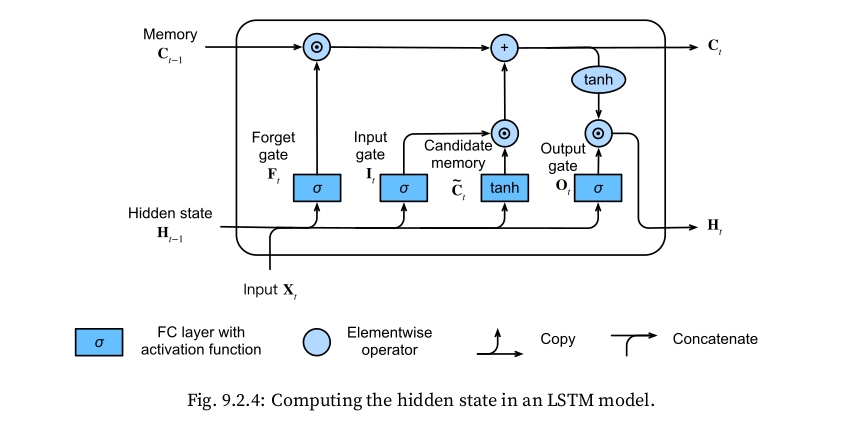

### (Source : Book - Dive into Deep Learning)

In [7]:
class LSTMCell (nn.Module):
    def __init__(self, input_size, hidden_size):
        # hidden size corresponds to no of neurons inside LSTM 
        super().__init__()
        
        # Instatiating the Weights for the LSTM cell
        self.Wi = nn.Linear(input_size+hidden_size, hidden_size)
        self.Wf = nn.Linear(input_size+hidden_size, hidden_size)
        self.Wo = nn.Linear(input_size+hidden_size, hidden_size)
        self.Wc = nn.Linear(input_size+hidden_size, hidden_size)

    def forward(self, Xt, ht_1, Ct_1):
        # Combining Input and Hidden State from prev time step
        combined = torch.cat((Xt, ht_1), 1)

        # Computing Gates
        It = torch.sigmoid(self.Wi(combined))
        Ft = torch.sigmoid(self.Wf(combined))
        Ot = torch.sigmoid(self.Wo(combined))

        # Computing candidate memory cell
        Ct_tilde = torch.tanh(self.Wc(combined))

        # Computing Cell and Hidden State 
        Ct = Ft * Ct_1 + It * Ct_tilde
        ht = Ot * torch.tanh(Ct)

        return ht, Ct

In [8]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)

    def forward(self, x):
        batch_size = x.size(0)
        seq_len = x.size(1)
        outputs = []

        # initializing hidden state and cell state
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            # Processing one timestep at a time
            h, c = self.cell(x[:, t, :],h,c)
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1)

        return outputs
        

In [9]:
class LSTMModel(nn.Module):
    def __init__(self,input_size, hidden_size_1, hidden_size_2,output_size):
        super().__init__()

        # Instantiating LSTM and Fully Connected
        self.lstm1 = LSTM(input_size, hidden_size_1)
        self.lstm2 = LSTM(hidden_size_1, hidden_size_2)
        self.fc = nn.Linear(hidden_size_2, output_size)

    def forward(self,x):
        h1 = self.lstm1(x)
        h2 = self.lstm2(h1)
        
        h_last = h2[:, -1, :]
        output = self.fc(h_last)
        return output

In [10]:
# Hyperparameters 
lr = 1e-3
epochs = 200 

In [11]:
def validate_model(model, dl, criterion):
    running_loss = 0
    model.eval()
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
    
            running_loss += loss.item()

    return running_loss/len(dl)

In [12]:
def evaluate_metrics (model, optimizer, dl):
    mse_loss_function = nn.MSELoss()
    mae_loss_function = nn.L1Loss()

    predictions = []
    targets = []
    
    model.eval()
    
    running_mse_loss = 0
    running_mae_loss = 0
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
            
            y_hat = model(X)
    
            predictions.append(y_hat.cpu().numpy())
            targets.append(y.cpu().numpy())
    
            running_mse_loss += mse_loss_function(y_hat, y).item()
            running_mae_loss += mae_loss_function(y_hat, y).item()

    y_true = np.concatenate(targets, axis=0)
    y_pred = np.concatenate(predictions, axis=0)

    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - rss / tss
    
    loss_mse = running_mse_loss/len(dl)
    loss_mae = running_mae_loss/len(dl)
    
    return r2, loss_mae, loss_mse

In [13]:
def train_model(model, train_dl, val_dl, criterion, optimizer, epochs):
    val_loss = []
    train_loss = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X, y in train_dl:
            X = X.to(device)
            y = y.to(device)
        
            optimizer.zero_grad()
            
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
        
            running_loss += loss.item()
            
            optimizer.step()
            
        cur_val_loss = validate_model(model, val_dl, criterion)
        val_loss.append(cur_val_loss)

        cur_train_loss = running_loss/len(train_dl)
        train_loss.append(cur_train_loss)
        
        print("EPOCH", epoch, "|" , "Validation Loss", cur_val_loss, "|", "Training Loss", cur_train_loss)
    return val_loss, train_loss
    

In [14]:
model = LSTMModel(input_size, hidden_size_1, hidden_size_2 ,output_len).to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [15]:
## weight decay 1e-5 : lr 1e-3 ===> Loss 0.1596598414358396 
## weight decay 1e-3 : lr 1e-3 ===> Loss 0.1526598414358396 for 100 epochs
## l_R 5e-3 ======================> Loss 0.043566268705664685 for 2 stacks of LSTM and 128, 128
## hidden size 2 -> 128 and 100 epochs lr=1e-3 ---> Loss 0.014049124222185919 
## everythnig same but lr = 5e-3 > oscillated around Loss 0.05392180064250355
## Loss 0.05245084989339155
## Loss 0.05558169242086311
## Loss 0.052443967356691046
## l_r = 1e-4  0.042 
### These all are MSE losses

In [ ]:
val_loss, train_loss = train_model(model, train_dl, val_dl,criterion, optimizer, epochs)
r2, mae, mse = evaluate_metrics(model, optimizer, test_dl)

EPOCH 0 | Validation Loss 0.044325358097218666 | Training Loss 0.09561330556172652
EPOCH 1 | Validation Loss 0.03971027739151764 | Training Loss 0.03735119656236573
EPOCH 2 | Validation Loss 0.03532510496493132 | Training Loss 0.03176019643105923
